<a href="https://colab.research.google.com/github/henryparfait/Time-Series-Forecasting/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Exploratory analysis

Uses the matrix built in notebook 01. CPU runtime is enough. Figures are saved to
`MyDrive/milan_forecasting/figures/`, and all key numbers go to `eda_summary.json`.

**Leakage note:** the required descriptive plots use the full period, but every statistic
that informs modelling decisions (seasonality strength, stationarity tests, area
characteristics) is computed on **Nov 1 – Dec 15 only**, so the test week (Dec 16–22) is never used.

In [ ]:
# ---- 1. Setup -------------------------------------------------------------------------
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, requests
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib.collections import PolyCollection
from google.colab import drive
drive.mount('/content/drive')
warnings.filterwarnings('ignore')

PROJECT_DIR = Path('/content/drive/MyDrive/milan_forecasting')
PROC_DIR, FIG_DIR = PROJECT_DIR / 'processed', PROJECT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
BASE = 'https://dataverse.harvard.edu'

M = np.load(PROC_DIR / 'internet_matrix.npy', mmap_mode='r')      # memory-mapped: not loaded fully into RAM
N_SQ, N_INT = M.shape
TIME = pd.date_range('2013-11-01 00:00', periods=N_INT, freq='10min')   # naive local (Europe/Rome) time
sel_info = json.load(open(PROC_DIR / 'selected_squares.json'))
TOP3, SELECTED = sel_info['top3'], sel_info['selected']
TOP = TOP3[0]
TRAIN_END = pd.Timestamp('2013-12-16 00:00')                      # test week starts here
train_mask = TIME < TRAIN_END

series = {s: pd.Series(np.asarray(M[s - 1], dtype=np.float64), index=TIME, name=f'sq_{s}') for s in SELECTED}
totals = pd.read_csv(PROC_DIR / 'square_totals.csv', index_col=0)['total_internet']
summary = {'top3': TOP3, 'selected': SELECTED}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def save(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches='tight'); plt.show()
print('Top-3:', TOP3, '| selected:', SELECTED)

Mounted at /content/drive
Top-3: [5161, 5059, 5259] | selected: [5161, 5059, 5259, 4159, 4556]


## 2.1 Distribution of total Internet traffic across the 10,000 squares

n_squares             1.000000e+04
zero_total_squares    0.000000e+00
min                   2.136270e+02
p25                   1.181020e+05
median                2.778711e+05
mean                  5.552894e+05
p75                   5.778956e+05
p99                   4.698732e+06
max                   1.274006e+07
mean_over_median      1.998000e+00
skewness              4.265000e+00
gini                  6.080000e-01
share_top_1pct        1.100000e-01
share_top_10pct       4.840000e-01
share_bottom_50pct    1.160000e-01


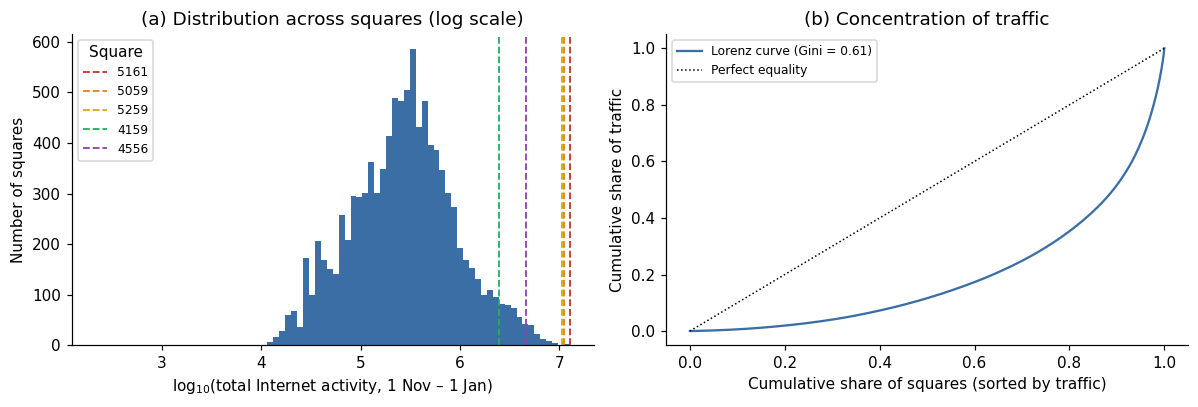

In [ ]:
# ---- 2. Distribution statistics + Figure 1 ----------------------------------------------
x = totals.to_numpy(dtype=np.float64)
xs = np.sort(x)
n = len(xs)
gini = (2 * np.sum(np.arange(1, n + 1) * xs) / (n * xs.sum())) - (n + 1) / n
share = lambda p: xs[-int(n * p):].sum() / xs.sum()
dist = {'n_squares': n, 'zero_total_squares': int((x == 0).sum()),
        'min': xs[0], 'p25': np.percentile(x, 25), 'median': np.median(x), 'mean': x.mean(),
        'p75': np.percentile(x, 75), 'p99': np.percentile(x, 99), 'max': xs[-1],
        'mean_over_median': x.mean() / np.median(x),
        'skewness': float(pd.Series(x).skew()), 'gini': gini,
        'share_top_1pct': share(0.01), 'share_top_10pct': share(0.10), 'share_bottom_50pct': xs[:n // 2].sum() / xs.sum()}
summary['distribution'] = {k: float(v) for k, v in dist.items()}
print(pd.Series(dist).round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
pos = x[x > 0]
ax[0].hist(np.log10(pos), bins=80, color='#3b6ea5')
for s, c in zip(SELECTED, ['#c0392b', '#e67e22', '#d4ac0d', '#27ae60', '#8e44ad']):
    ax[0].axvline(np.log10(totals[s]), color=c, lw=1.2, ls='--', label=f'{s}')
ax[0].set(xlabel='log$_{10}$(total Internet activity, 1 Nov – 1 Jan)', ylabel='Number of squares',
          title='(a) Distribution across squares (log scale)')
ax[0].legend(title='Square', fontsize=8)
cum = np.cumsum(xs) / xs.sum()
ax[1].plot(np.arange(1, n + 1) / n, cum, color='#3b6ea5', label=f'Lorenz curve (Gini = {gini:.2f})')
ax[1].plot([0, 1], [0, 1], 'k:', lw=1, label='Perfect equality')
ax[1].set(xlabel='Cumulative share of squares (sorted by traffic)', ylabel='Cumulative share of traffic',
          title='(b) Concentration of traffic')
ax[1].legend(fontsize=8)
fig.tight_layout(); save(fig, 'fig01_distribution.png')

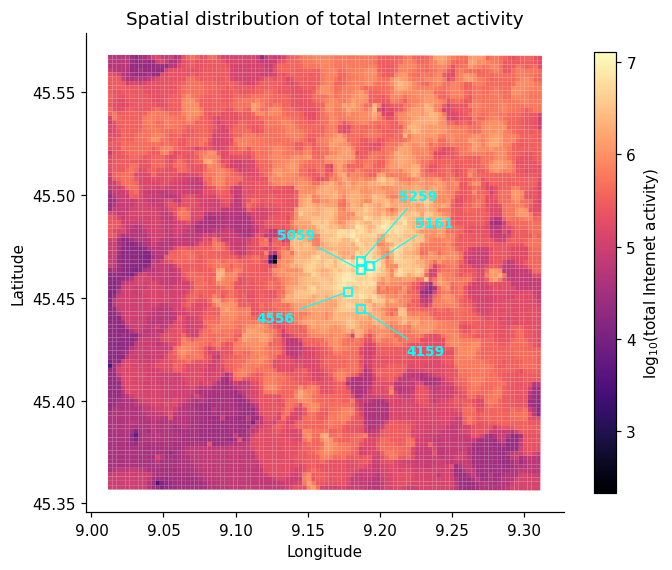

In [ ]:
# ---- 3. Spatial map (Milano grid GeoJSON from Dataverse, doi:10.7910/DVN/QJWLFU) --------
LABEL_OFFSETS = [(30, 25), (-55, 20), (25, 40), (30, -30), (-60, -20)]   # spread labels of neighbouring squares
geo_path = PROC_DIR / 'milano-grid.geojson'   # if the API is blocked (403), download it manually into this folder
try:
    if not geo_path.exists():
        r = requests.get(f'{BASE}/api/datasets/:persistentId/',
                         params={'persistentId': 'doi:10.7910/DVN/QJWLFU'}, timeout=60)
        r.raise_for_status()
        files = [f['dataFile'] for f in r.json()['data']['latestVersion']['files']]
        gf = [f for f in files if f['filename'].lower().endswith(('.geojson', '.json'))][0]
        geo_path.write_bytes(requests.get(f"{BASE}/api/access/datafile/{gf['id']}", timeout=300).content)
    feats = json.load(open(geo_path))['features']
    ids = np.array([f['properties'].get('cellId', f['properties'].get('id')) for f in feats], dtype=int)
    verts = [np.array(f['geometry']['coordinates'][0])[:, :2] for f in feats]
    vals = np.log10(np.maximum(totals.reindex(ids).to_numpy(dtype=float), 1))
    fig, ax = plt.subplots(figsize=(7, 6.5))
    pc = PolyCollection(verts, array=vals, cmap='magma', edgecolors='none')
    ax.add_collection(pc); ax.autoscale_view()
    lat0 = np.mean([v[:, 1].mean() for v in verts]); ax.set_aspect(1 / np.cos(np.radians(lat0)))
    cent = {i: v.mean(axis=0) for i, v in zip(ids, verts)}
    for s, off in zip(SELECTED, LABEL_OFFSETS):
        cx, cy = cent[s]
        ax.plot(cx, cy, 's', mfc='none', mec='cyan', ms=5, mew=1.2)
        ax.annotate(str(s), (cx, cy), xytext=off, textcoords='offset points', color='cyan', fontsize=9, weight='bold',
                    arrowprops={'arrowstyle': '-', 'color': 'cyan', 'lw': 0.8})
    fig.colorbar(pc, ax=ax, shrink=0.8, label='log$_{10}$(total Internet activity)')
    ax.set(xlabel='Longitude', ylabel='Latitude', title='Spatial distribution of total Internet activity')
    summary['centroids_lonlat'] = {int(s): [float(c) for c in cent[s]] for s in SELECTED}
    save(fig, 'fig02_spatial_map.png')
except Exception as e:
    print('GeoJSON map failed, using ID-grid fallback (orientation not guaranteed):', e)
    fig, ax = plt.subplots(figsize=(6.5, 6))
    im = ax.imshow(np.log10(np.maximum(totals.sort_index().to_numpy().reshape(100, 100), 1)), origin='lower', cmap='magma')
    for s, off in zip(SELECTED, LABEL_OFFSETS):
        ax.annotate(str(s), ((s - 1) % 100, (s - 1) // 100), xytext=off, textcoords='offset points', color='cyan',
                    fontsize=9, weight='bold', arrowprops={'arrowstyle': '-', 'color': 'cyan', 'lw': 0.8})
    fig.colorbar(im, ax=ax, label='log$_{10}$(total)'); ax.set_title('Total Internet activity by grid cell')
    save(fig, 'fig02_spatial_map.png')

## 2.2 First two weeks for the five squares, and how their dynamics differ

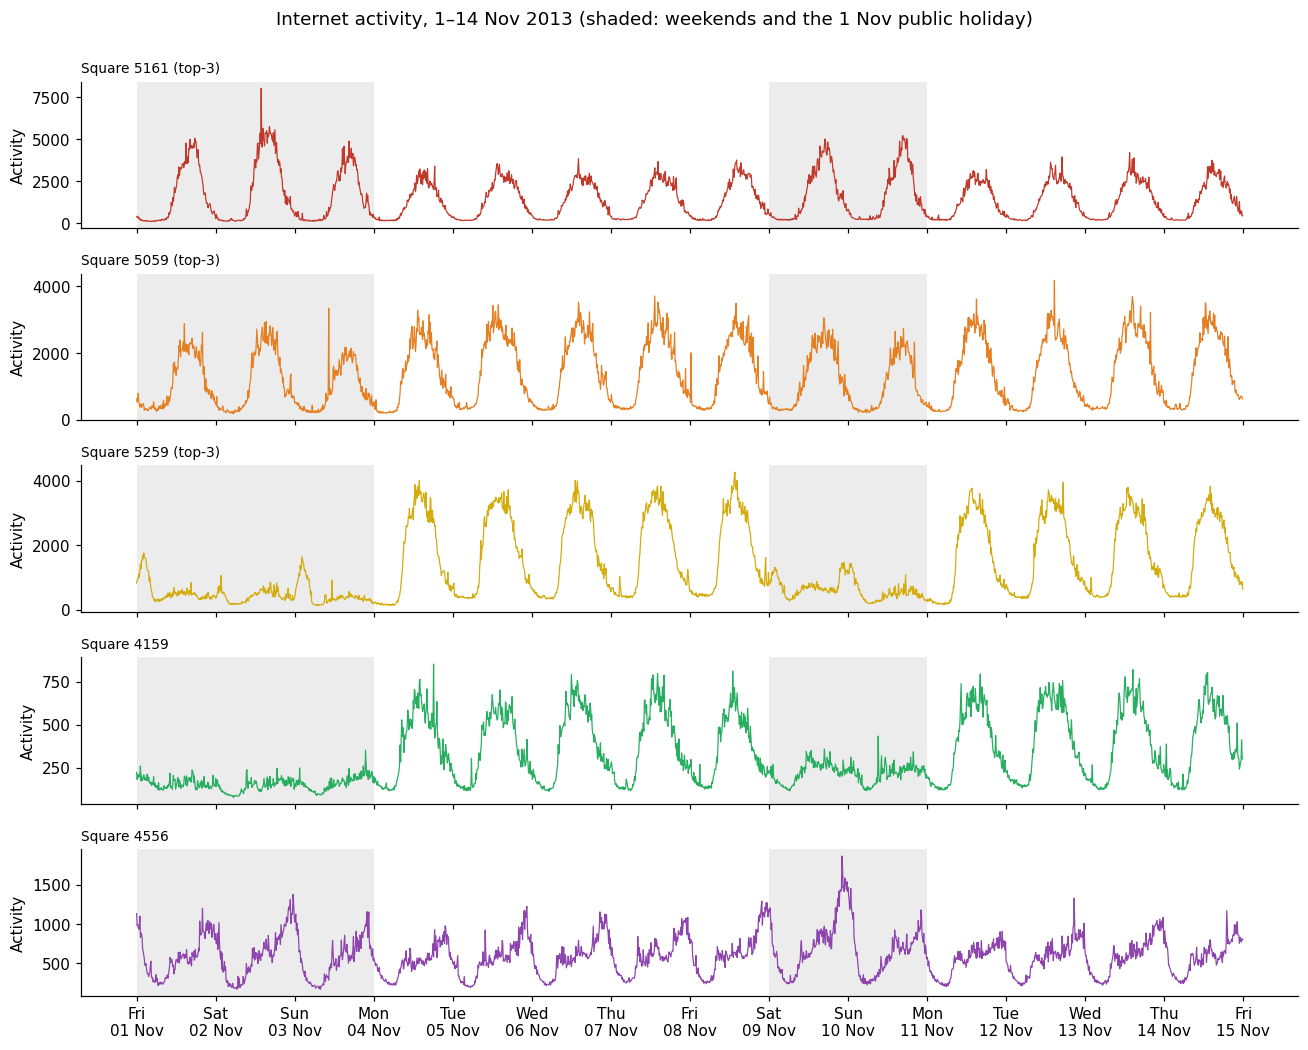

In [ ]:
# ---- 4. Figure 3: first two weeks (1–14 Nov) ------------------------------------------
two = slice('2013-11-01', '2013-11-14 23:50')
colors = dict(zip(SELECTED, ['#c0392b', '#e67e22', '#d4ac0d', '#27ae60', '#8e44ad']))
fig, axes = plt.subplots(len(SELECTED), 1, figsize=(12, 1.9 * len(SELECTED)), sharex=True)
for ax, s in zip(axes, SELECTED):
    y = series[s][two]
    ax.plot(y.index, y.values, color=colors[s], lw=0.8)
    for d in pd.date_range('2013-11-01', '2013-11-14'):
        if d.dayofweek >= 5 or d == pd.Timestamp('2013-11-01'):
            ax.axvspan(d, d + pd.Timedelta(days=1), color='grey', alpha=0.15, lw=0)
    tag = ' (top-3)' if s in TOP3 else ''
    ax.set_ylabel('Activity'); ax.set_title(f'Square {s}{tag}', loc='left', fontsize=9)
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d %b'))
fig.suptitle('Internet activity, 1–14 Nov 2013 (shaded: weekends and the 1 Nov public holiday)', y=1.0)
fig.tight_layout(); save(fig, 'fig03_first_two_weeks.png')

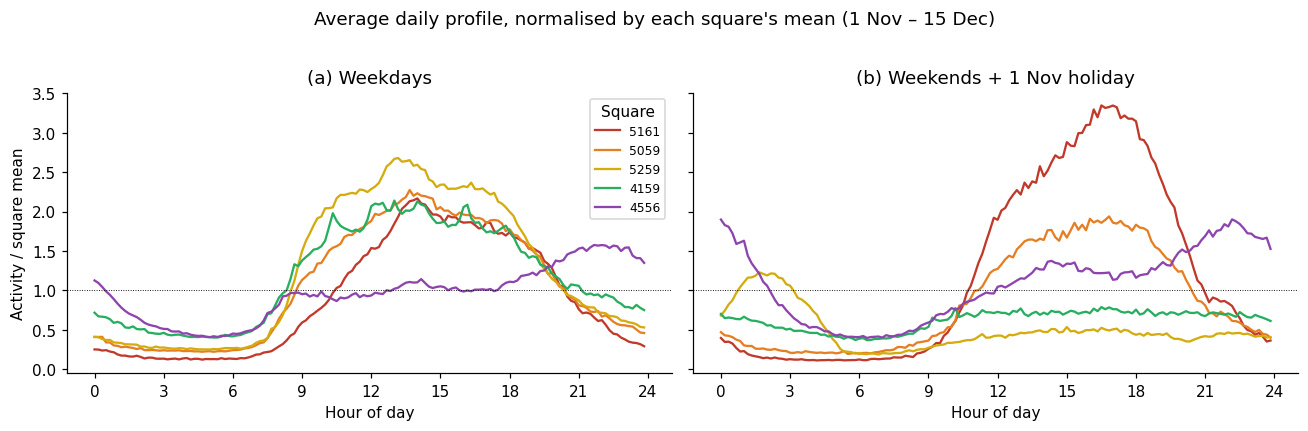

,top3,mean,std,cv,min,max,peak_time_weekday,peak_to_night_ratio,weekend_to_weekday_ratio,acf_lag1,acf_lag144_1day,acf_lag1008_1week,share_below_10pct_of_mean
square,,,,,,,,,,,,,
5161,True,1540.281,1412.708,0.917,93.163,8044.070,14:00,17.164,1.350,0.984,0.870,0.798,0.029
5059,True,1366.181,977.836,0.716,179.092,4666.121,13:40,10.097,0.811,0.975,0.903,0.793,0.000
5259,True,1334.876,1129.478,0.846,115.386,4442.096,13:10,6.368,0.401,0.990,0.668,0.753,0.002
4159,False,316.891,185.944,0.587,80.286,940.891,13:00,4.891,0.525,0.970,0.730,0.779,0.000
4556,False,576.049,245.510,0.426,156.364,1868.742,21:40,3.226,1.126,0.945,0.762,0.765,0.000


In [ ]:
# ---- 5. Figure 4 + Table: average daily profile and area characteristics (train period) --
def acf_at(y, k):
    y = y - y.mean(); return float(np.dot(y[:-k], y[k:]) / np.dot(y, y))

rows, fig, axes = [], *plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for s in SELECTED:
    y = series[s][train_mask]
    slot = y.index.hour * 6 + y.index.minute // 10
    wkend = (y.index.dayofweek >= 5) | (y.index.normalize() == pd.Timestamp('2013-11-01'))
    prof_wd = y[~wkend].groupby(slot[~wkend]).mean()
    prof_we = y[wkend].groupby(slot[wkend]).mean()
    hours = np.arange(144) / 6
    axes[0].plot(hours, prof_wd / y.mean(), color=colors[s], label=str(s))
    axes[1].plot(hours, prof_we / y.mean(), color=colors[s], label=str(s))
    night = y[(y.index.hour >= 3) & (y.index.hour < 5)].mean()
    rows.append({'square': s, 'top3': s in TOP3, 'mean': y.mean(), 'std': y.std(), 'cv': y.std() / y.mean(),
                 'min': y.min(), 'max': y.max(),
                 'peak_time_weekday': f'{int(prof_wd.idxmax()) // 6:02d}:{int(prof_wd.idxmax()) % 6 * 10:02d}',
                 'peak_to_night_ratio': prof_wd.max() / night,
                 'weekend_to_weekday_ratio': y[wkend].mean() / y[~wkend].mean(),
                 'acf_lag1': acf_at(y.values, 1), 'acf_lag144_1day': acf_at(y.values, 144),
                 'acf_lag1008_1week': acf_at(y.values, 1008),
                 'share_below_10pct_of_mean': float((y < 0.1 * y.mean()).mean())})
for ax, t in zip(axes, ['(a) Weekdays', '(b) Weekends + 1 Nov holiday']):
    ax.set(xlabel='Hour of day', title=t, xticks=range(0, 25, 3)); ax.axhline(1, color='k', lw=0.6, ls=':')
axes[0].set_ylabel('Activity / square mean'); axes[0].legend(title='Square', fontsize=8)
fig.suptitle('Average daily profile, normalised by each square\'s mean (1 Nov – 15 Dec)', y=1.02)
fig.tight_layout(); save(fig, 'fig04_daily_profiles.png')

chars = pd.DataFrame(rows).set_index('square')
chars.to_csv(PROJECT_DIR / 'area_characteristics.csv')
summary['area_characteristics'] = json.loads(chars.to_json(orient='index'))
chars.round(3)

## 2.3 Additional analyses on the highest-traffic square
**Analysis A: autocorrelation and multi-seasonal decomposition.** How much of the signal is
predictable from its own past, and at which lags? This determines the input window length and whether weekly
information is needed.

**Analysis B: stationarity.** Does the series need differencing or transformation? This determines
the ARIMA differencing orders and the normalisation used for the neural models.

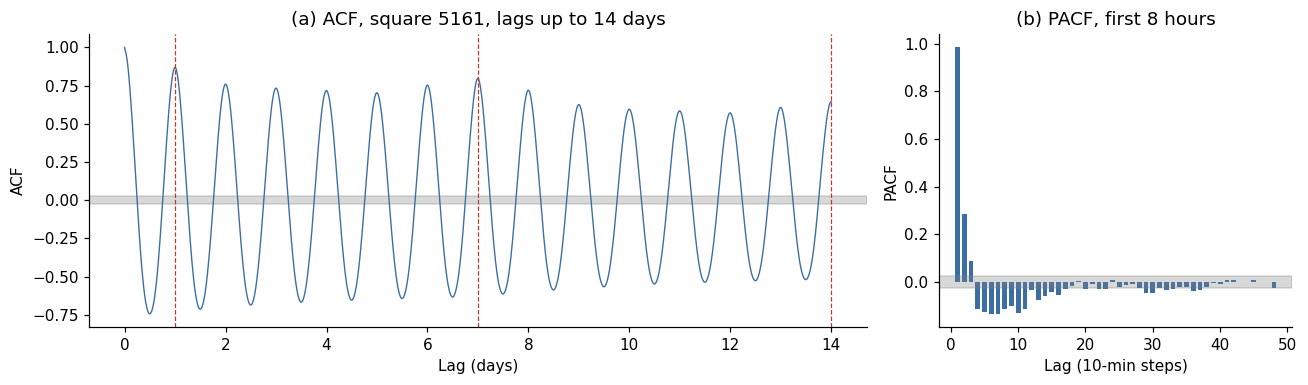

{
 "acf_lag1": 0.9843626300182141,
 "acf_lag6_1h": 0.935170270159504,
 "acf_lag72_12h": -0.7445237425626235,
 "acf_lag144_1d": 0.8698205189313971,
 "acf_lag1008_1w": 0.7978868235446056,
 "acf_lag2016_2w": 0.6443556654227179,
 "significant_pacf_lags_1_to_48": [
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  20,
  22,
  23,
  28,
  29,
  30,
  31,
  32,
  33,
  36,
  37,
  48
 ]
}


In [ ]:
# ---- 6. Analysis A: ACF/PACF (Figure 5) --------------------------------------------------
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
y_top = series[TOP][train_mask]
ac = acf(y_top.values, nlags=2 * 1008, fft=True)
pc = pacf(y_top.values, nlags=48, method='ywm')
conf = 1.96 / np.sqrt(len(y_top))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={'width_ratios': [2.2, 1]})
lags = np.arange(len(ac))
ax[0].plot(lags / 144, ac, color='#3b6ea5', lw=0.9)
ax[0].axhspan(-conf, conf, color='grey', alpha=0.3)
for k in (1, 7, 14):
    ax[0].axvline(k, color='#c0392b', ls='--', lw=0.8)
ax[0].set(xlabel='Lag (days)', ylabel='ACF', title=f'(a) ACF, square {TOP}, lags up to 14 days')
ax[1].bar(np.arange(1, len(pc)), pc[1:], color='#3b6ea5', width=0.7)
ax[1].axhspan(-conf, conf, color='grey', alpha=0.3)
ax[1].set(xlabel='Lag (10-min steps)', ylabel='PACF', title='(b) PACF, first 8 hours')
fig.tight_layout(); save(fig, 'fig05_acf_pacf.png')

sig_pacf = [int(i) for i in np.where(np.abs(pc[1:]) > conf)[0] + 1]
summary['analysis_A_acf'] = {'acf_lag1': ac[1], 'acf_lag6_1h': ac[6], 'acf_lag72_12h': ac[72],
                             'acf_lag144_1d': ac[144], 'acf_lag1008_1w': ac[1008], 'acf_lag2016_2w': ac[2016],
                             'significant_pacf_lags_1_to_48': sig_pacf}
summary['analysis_A_acf'] = {k: (float(v) if not isinstance(v, list) else v) for k, v in summary['analysis_A_acf'].items()}
print(json.dumps(summary['analysis_A_acf'], indent=1))

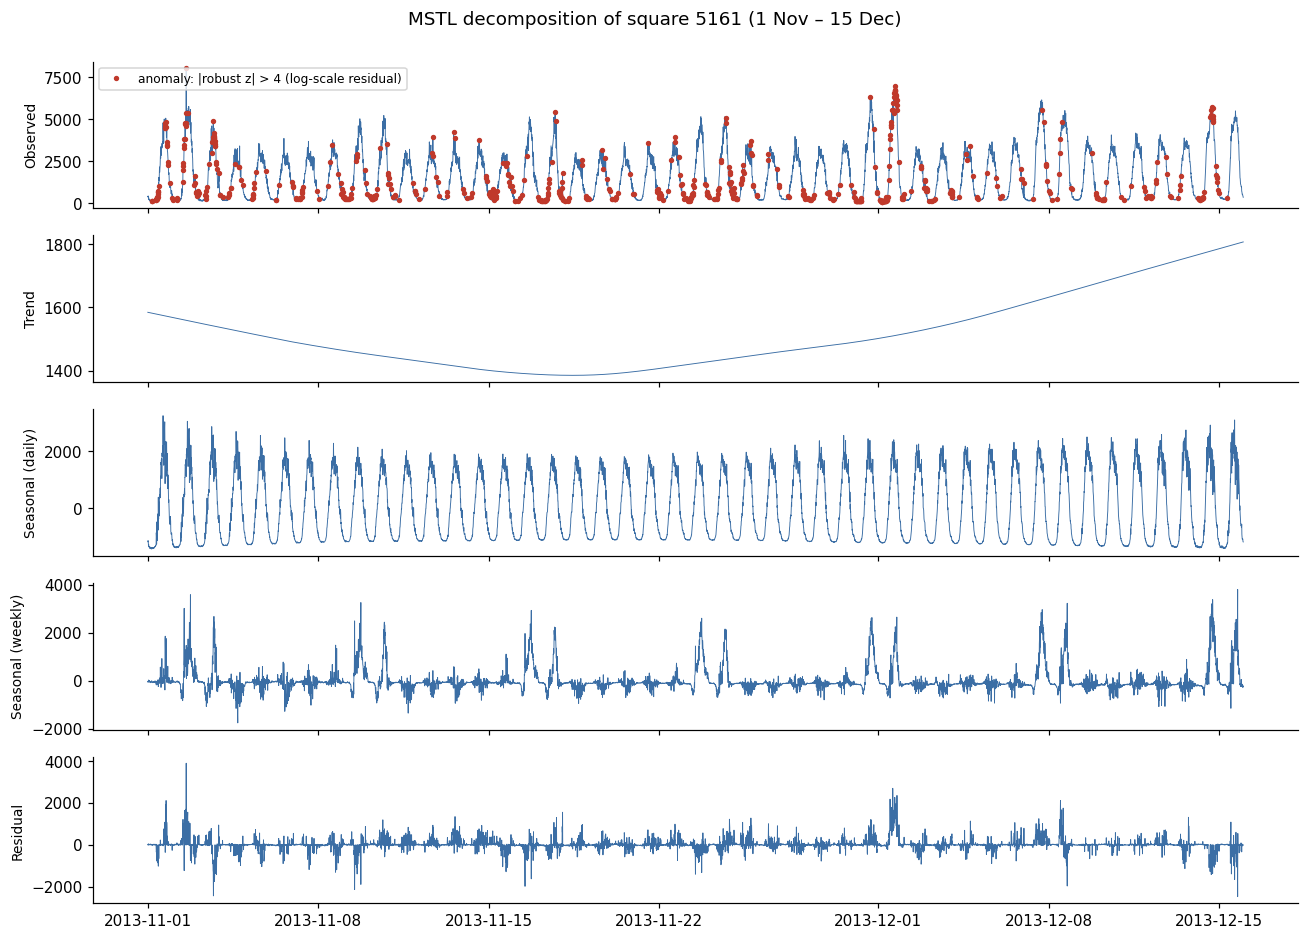

{
 "daily_seasonal_strength": 0.9400080771986035,
 "weekly_seasonal_strength": 0.7229795508247687,
 "trend_strength": 0.11083308488900101,
 "share_variance_residual": 0.04300411732641323,
 "n_anomalous_intervals": 653,
 "share_anomalous": 0.1007716049382716
}
            n_anomalous_intervals  max_abs_z
2013-11-18                     11  30.047080
2013-11-15                     25  25.363057
2013-11-25                     22  23.233025
2013-11-01                     28  21.245250
2013-11-03                     33  20.945222
2013-12-04                     11  19.091910
2013-12-06                      7  17.046876
2013-12-02                     15  15.952826
2013-11-09                     21  15.279294
2013-11-24                     23  14.802298


In [ ]:
# ---- 7. Analysis A (cont.): MSTL decomposition with daily + weekly seasonality (Figure 6) --
try:
    from statsmodels.tsa.seasonal import MSTL
    dec = MSTL(y_top, periods=(144, 1008), stl_kwargs={'robust': True}).fit()
    seas = {'daily': dec.seasonal.iloc[:, 0], 'weekly': dec.seasonal.iloc[:, 1]}
except ImportError:                                    # older statsmodels: daily STL only
    from statsmodels.tsa.seasonal import STL
    dec = STL(y_top, period=144, robust=True).fit()
    seas = {'daily': dec.seasonal}
trend, resid = dec.trend, dec.resid

# Anomalies are detected on the LOG series: residual size scales with the traffic level (daily mean-std r = 0.98),
# so a single threshold on raw residuals would flag almost every busy interval.
try:
    resid_log = MSTL(np.log1p(y_top), periods=(144, 1008), stl_kwargs={'robust': True}).fit().resid
except NameError:
    resid_log = STL(np.log1p(y_top), period=144, robust=True).fit().resid

strength = {f'{k}_seasonal_strength': float(max(0, 1 - resid.var() / (v + resid).var())) for k, v in seas.items()}
strength['trend_strength'] = float(max(0, 1 - resid.var() / (trend + resid).var()))
strength['share_variance_residual'] = float(resid.var() / y_top.var())

# anomalies: residuals beyond 4 robust standard deviations (MAD-based)
mad = 1.4826 * np.median(np.abs(resid_log - resid_log.median()))
z = (resid_log - resid_log.median()) / mad
anom = z[np.abs(z) > 4]
anom_days = anom.groupby(anom.index.date).agg(['size', lambda v: float(v.abs().max())])
anom_days.columns = ['n_anomalous_intervals', 'max_abs_z']
strength['n_anomalous_intervals'] = int(len(anom)); strength['share_anomalous'] = float(len(anom) / len(z))
summary['analysis_A_decomposition'] = strength
summary['anomalous_days'] = {str(k): v for k, v in anom_days.to_dict('index').items()}

parts = [('Observed', y_top), ('Trend', trend)] + [(f'Seasonal ({k})', v) for k, v in seas.items()] + [('Residual', resid)]
fig, axes = plt.subplots(len(parts), 1, figsize=(12, 1.7 * len(parts)), sharex=True)
for ax, (name, v) in zip(axes, parts):
    ax.plot(v.index, v.values, lw=0.6, color='#3b6ea5'); ax.set_ylabel(name, fontsize=9)
axes[0].plot(anom.index, y_top[anom.index], 'o', color='#c0392b', ms=2.5, label='anomaly: |robust z| > 4 (log-scale residual)')
axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle(f'MSTL decomposition of square {TOP} (1 Nov – 15 Dec)', y=1.0)
fig.tight_layout(); save(fig, 'fig06_decomposition.png')
print(json.dumps(strength, indent=1)); print(anom_days.sort_values('max_abs_z', ascending=False).head(10))

In [ ]:
# ---- 8. Analysis B: stationarity tests (ADF: H0 unit root; KPSS: H0 stationary) ----------
def tests(v):
    v = pd.Series(v).dropna().values
    adf = adfuller(v, autolag='AIC')
    kp = kpss(v, regression='c', nlags='auto')
    return {'ADF stat': adf[0], 'ADF p': adf[1], 'KPSS stat': kp[0], 'KPSS p': kp[1],
            'ADF says': 'stationary' if adf[1] < 0.05 else 'unit root',
            'KPSS says': 'stationary' if kp[1] > 0.05 else 'non-stationary'}

variants = {
    'raw': y_top,
    'log1p': np.log1p(y_top),
    'first difference (lag 1)': y_top.diff(1),
    'daily seasonal diff (lag 144)': y_top.diff(144),
    'weekly seasonal diff (lag 1008)': y_top.diff(1008),
    'lag-144 diff then lag-1 diff': y_top.diff(144).diff(1),
}
stat_tab = pd.DataFrame({k: tests(v) for k, v in variants.items()}).T
stat_tab.to_csv(PROJECT_DIR / 'stationarity_tests.csv')
summary['analysis_B_stationarity'] = json.loads(stat_tab.to_json(orient='index'))

# heteroscedasticity check: does the daily std grow with the daily mean? (motivates log / scaling)
daily = y_top.resample('D').agg(['mean', 'std'])
summary['analysis_B_corr_daily_mean_std'] = float(daily['mean'].corr(daily['std']))
print('Correlation between daily mean and daily std:', round(summary['analysis_B_corr_daily_mean_std'], 3))
stat_tab

/tmp/ipykernel_488/1837566990.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kp = kpss(v, regression='c', nlags='auto')
/tmp/ipykernel_488/1837566990.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kp = kpss(v, regression='c', nlags='auto')
/tmp/ipykernel_488/1837566990.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kp = kpss(v, regression='c', nlags='auto')
/tmp/ipykernel_488/1837566990.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kp = kpss(v, regression='c', nlags='auto')
/tmp/ipykern

Correlation between daily mean and daily std: 0.976


,ADF stat,ADF p,KPSS stat,KPSS p,ADF says,KPSS says
raw,-17.116195,0.0,0.141691,0.1,stationary,stationary
log1p,-21.703677,0.0,0.040209,0.1,stationary,stationary
first difference (lag 1),-12.591749,0.0,0.004525,0.1,stationary,stationary
daily seasonal diff (lag 144),-10.339064,0.0,0.05247,0.1,stationary,stationary
weekly seasonal diff (lag 1008),-9.958744,0.0,0.830021,0.01,stationary,non-stationary
lag-144 diff then lag-1 diff,-17.78052,0.0,0.007853,0.1,stationary,stationary


In [ ]:
# ---- 9. Save summary (upload eda_summary.json + the figures folder back to the chat) -----
def clean(o):
    if isinstance(o, dict): return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [clean(v) for v in o]
    if isinstance(o, (np.floating, np.integer)): return o.item()
    return o
(PROJECT_DIR / 'eda_summary.json').write_text(json.dumps(clean(summary), indent=1, default=str))
print('Saved', PROJECT_DIR / 'eda_summary.json')
print(sorted(p.name for p in FIG_DIR.glob('*.png')))

Saved /content/drive/MyDrive/milan_forecasting/eda_summary.json
['fig01_distribution.png', 'fig02_spatial_map.png', 'fig03_first_two_weeks.png', 'fig04_daily_profiles.png', 'fig05_acf_pacf.png', 'fig06_decomposition.png', 'fig07_predictions_5161.png', 'fig08_predictions_5059.png', 'fig09_predictions_5259.png', 'fig10_error_by_hour.png', 'fig11_worst_day.png']
